In [ ]:
import numpy as np
perch_length = np.array([8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0, 21.0,
       21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5, 22.5, 22.7,
       23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5, 27.3, 27.5, 27.5,
       27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0, 36.5, 36.0, 37.0, 37.0,
       39.0, 39.0, 39.0, 40.0, 40.0, 40.0, 40.0, 42.0, 43.0, 43.0, 43.5,
       44.0])
perch_weight = np.array([5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 110.0,
       115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 130.0,
       150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 197.0,
       218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 514.0,
       556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 820.0,
       850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 1000.0,
       1000.0])

In [ ]:
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(perch_length, perch_weight, random_state=42)
train_input = train_input.reshape(-1, 1)
test_input = test_input.reshape(-1, 1)

from sklearn.neighbors import KNeighborsRegressor
knr = KNeighborsRegressor(n_neighbors=3)
knr.fit(train_input, train_target)
print(knr.predict([[50]]))
# 실제와 다른 결과값

[1033.33333333]


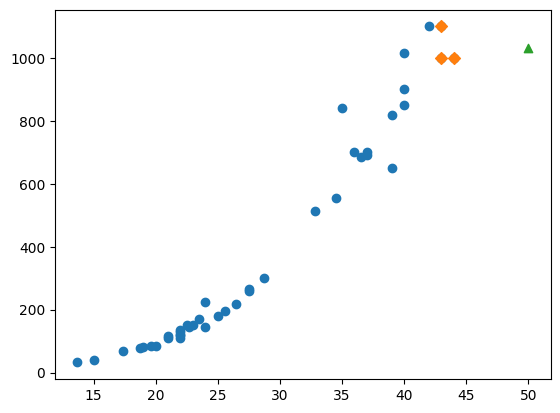

In [ ]:
import matplotlib.pyplot as plt
distances, indexes = knr.kneighbors([[50]])
plt.scatter(train_input, train_target)
plt.scatter(train_input[indexes], train_target[indexes], marker='D')
plt.scatter(50, 1033, marker='^') # 모델이 예측한 값 -> 전체적인 경향과 다름.
plt.show()

In [ ]:
print(np.mean(train_target[indexes])) # = print(knr.predict([[50]])) = print(lnr.predict[[100]])
# 새로운 샘플이 훈련 세트의 범위를 벗어나면 엉뚱한 값을 예측할 수 있음.
# 훈련 세트의 범위를 벗어난 상태에서는 어떤 값을 입력하든, 인접한 이웃이 같아 다 같은 값임.

1033.3333333333333


K최근접 이웃 알고리즘의 단점: 훈련세트의 벗어난 새로운 범위의 샘플은 예측하기 어려움
# 대안책: 선형 회귀
: 특성이 하나인 경우, 어떤 직선을 학습하는 알고리즘
: 선형회귀는 가중치(계수)와 타깃 사이의 관계가 1대1(선형)이라 선형회귀임.
  따라서 2차방정식인 다항회귀도 선형회귀임.

In [ ]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(train_input, train_target)
print(lr.predict([[50]]))

[1241.83860323]


In [ ]:
# 기울기, y절편
print(lr.coef_, lr.intercept_)

[39.01714496] -709.0186449535477


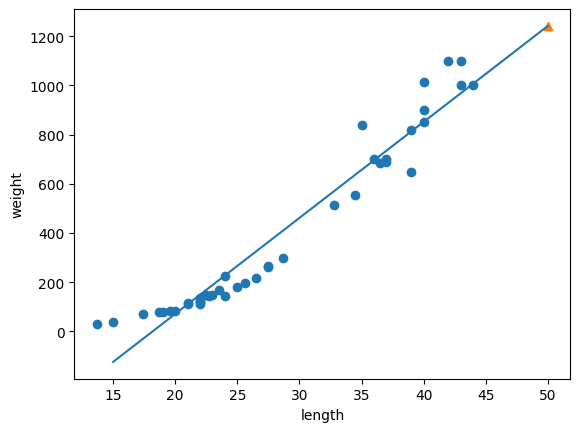

In [ ]:
plt.scatter(train_input, train_target)

# 길이 15~50까지의 모델이 학습한 직선 그리기
plt.plot([15, 50], [15*lr.coef_+lr.intercept_, 50*lr.coef_+lr.intercept_])

# 길이 50인 농어 예측값
plt.scatter(50, lr.predict([[50]]), marker='^')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [ ]:
print(lr.score(train_input, train_target))
print(lr.score(test_input, test_target))
# 훈련세트의 점수가 약간 더 크게 조금

0.939846333997604
0.8247503123313558


# 다항회귀
: 최적의 곡선 찾기

In [ ]:
# 2차 함수 -> 제곱한 항 필요
train_poly = np.column_stack((train_input**2, train_input))# 제곱 시에 브로드 캐스팅 적용됨.
test_poly = np.column_stack((test_input**2, test_input))

# 새로운 데이터를 훈련할 때 보통 다시 객체를 선언하거나 새로운 객체를 선언함.
lr2 = LinearRegression()
lr2.fit(train_poly, train_target)
print(lr2.predict([[50**2, 50]]))


[1573.98423528]


In [ ]:
print(lr2.coef_, lr2.intercept_) # 계수 = [2차항 계수, 1차항 계수]

[  1.01433211 -21.55792498] 116.0502107827827


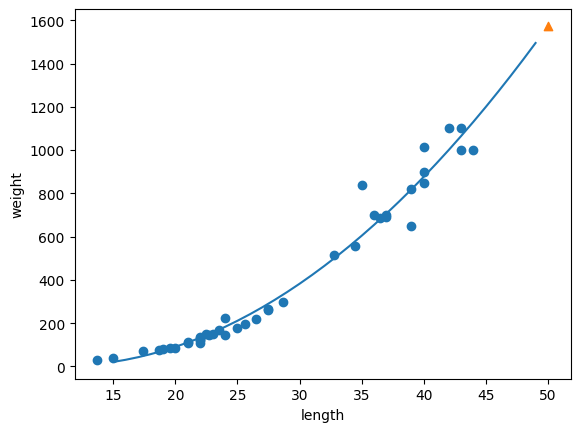

In [ ]:
# 곡선을 그리기 위해 15에서 49까지 정수 배열 만들기
point = np.arange(15,50)
# 산점도로 나타내기
plt.scatter(train_input, train_target)
coef=lr2.coef_
intercept=lr2.intercept_
plt.plot(point,coef[0]*point**2+coef[1]*point+intercept)
plt.scatter(50, lr2.predict([[50**2, 50]]), marker='^')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [ ]:
# 모델 평가
print(lr2.score(train_poly, train_target))
print(lr2.score(test_poly, test_target))
# 훈련세트, 테스트세트의 점수 모두 높아짐, 약간의 과소적합 상태임.

0.9706807451768623
0.9775935108325122
